## Plotting Loss curve

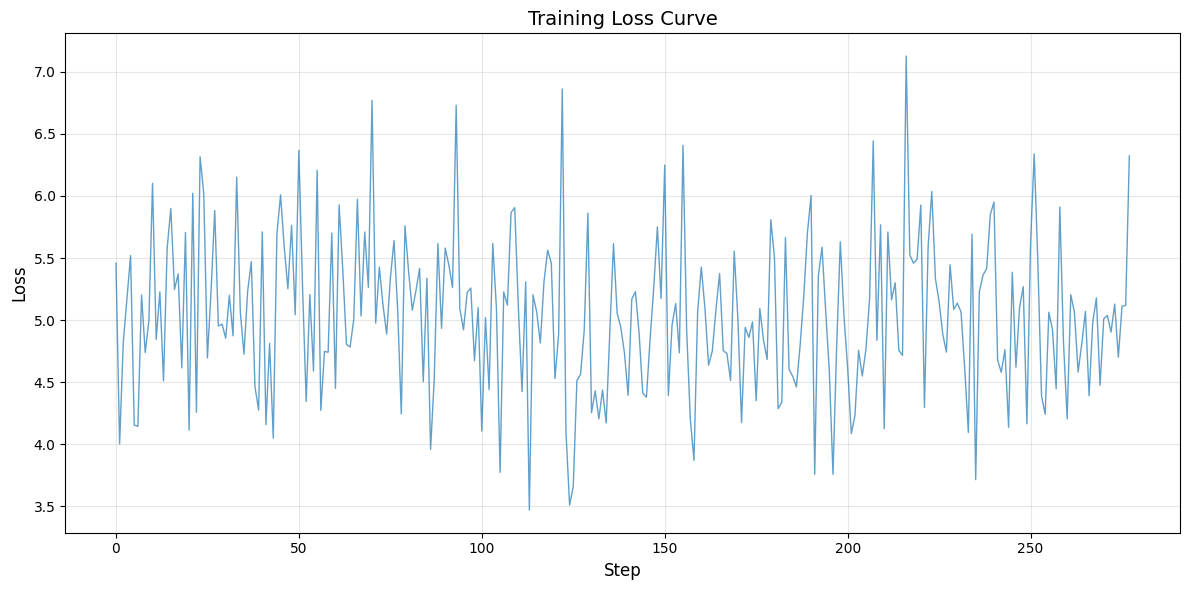

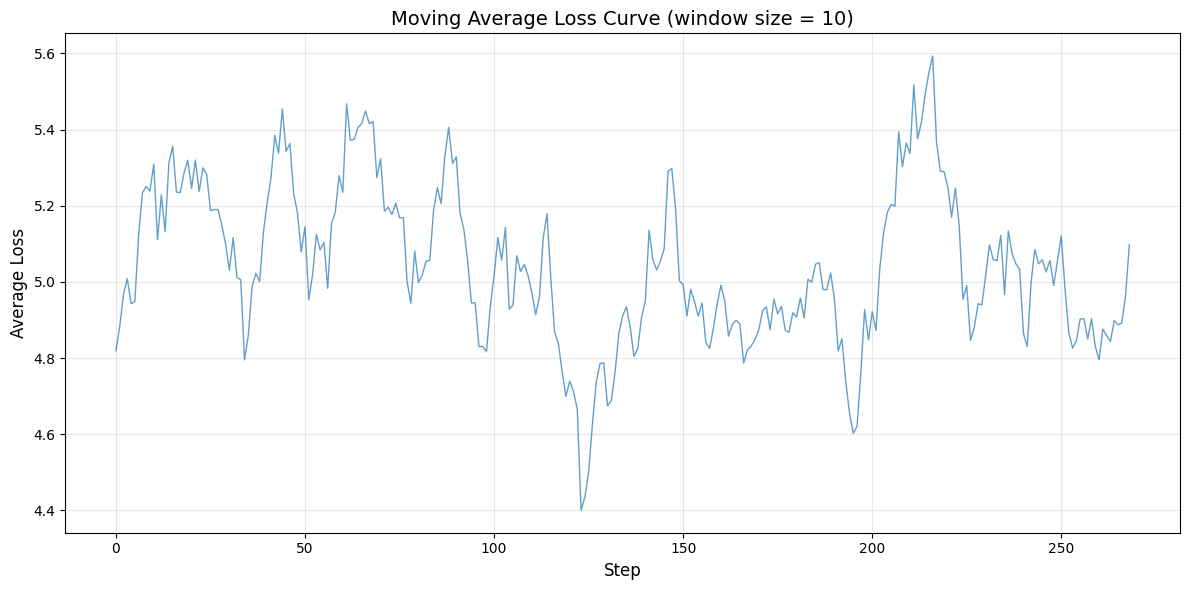

Total steps: 278
Min loss: 3.4685
Max loss: 7.1282
Mean loss: 5.0417
Final loss: 6.3234


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

log_path = "training_runs/mnist_training/mnist_training.csv"

# Extract experiment folder from log_path
experiment_dir = os.path.dirname(log_path)
if not experiment_dir.startswith('training_runs'):
    # Fallback: assume experiment name matches CSV filename
    csv_name = os.path.basename(log_path).replace('.csv', '')
    experiment_dir = f"training_runs/{csv_name}"

# Read the CSV file
df = pd.read_csv(log_path)

# Extract loss values in order (ignoring worker_id)
losses = df['loss'].values[:]
window_size = 10
average_losses = np.convolve(losses, np.ones(window_size)/window_size, mode='valid')

# Create step numbers (0, 1, 2, ...)
steps = np.arange(len(losses))

# Plot the loss curve
plt.figure(figsize=(12, 6))
plt.plot(steps, losses, linewidth=1, alpha=0.7)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot_path = os.path.join(experiment_dir, "loss_curve.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(steps[:len(average_losses)], average_losses, linewidth=1, alpha=0.7)
plt.xlabel('Step', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title(f'Moving Average Loss Curve (window size = {window_size})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot_path = os.path.join(experiment_dir, "moving_average_loss.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

# Print some statistics
print(f"Total steps: {len(losses)}")
print(f"Min loss: {losses.min():.4f}")
print(f"Max loss: {losses.max():.4f}")
print(f"Mean loss: {losses.mean():.4f}")
print(f"Final loss: {losses[-1]:.4f}")




## Plot per-worker loss graphs

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Use the same log_path as defined above, or specify a different one
log_path = "training_logs/main1.csv"

# Extract experiment folder from log_path
experiment_dir = os.path.dirname(log_path)
if not experiment_dir.startswith('training_runs'):
    # Fallback: assume experiment name matches CSV filename
    csv_name = os.path.basename(log_path).replace('.csv', '')
    experiment_dir = f"training_runs/{csv_name}"

# Read the CSV file
df = pd.read_csv(log_path) 

# Check if required columns exist
if 'worker_id' not in df.columns or 'loss' not in df.columns:
    raise ValueError(f"CSV file must contain 'worker_id' and 'loss' columns. Found columns: {df.columns.tolist()}")

# Filter out skipped samples (handle both string and boolean values)
if 'skipped' in df.columns:
    original_len = len(df)
    # Try different filtering approaches
    if df['skipped'].dtype == 'object':
        # Handle string values (case-insensitive)
        df_filtered = df[df['skipped'].astype(str).str.lower().isin(['false', '0', 'no', ''])].copy()
    else:
        # Handle boolean values
        df_filtered = df[df['skipped'] == False].copy()
    
    # Only use filtered data if it has rows, otherwise use all data
    if len(df_filtered) > 0:
        df = df_filtered
        print(f"Filtered out {original_len - len(df)} skipped samples")
    else:
        print("Warning: Filtering removed all data. Using all samples (including skipped).")

# Check if dataframe is empty
if len(df) == 0:
    raise ValueError("No data found in CSV file.")

# Get unique worker IDs and sort them
worker_ids = sorted(df['worker_id'].unique())
num_workers = len(worker_ids)

if num_workers == 0:
    raise ValueError("No workers found in the data.")

# Calculate global y-axis limits for consistent scaling
all_losses = df['loss'].values
global_ymin = all_losses.min() * 0.95  # Add 5% padding below
global_ymax = all_losses.max() * 1.05   # Add 5% padding above

# Determine grid layout (aim for roughly square grid)
cols = int(np.ceil(np.sqrt(num_workers)))
rows = int(np.ceil(num_workers / cols))

# Create subplots
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(5*cols, 4*rows), constrained_layout=True)

# Flatten axes array for easier iteration
# Handle different subplot configurations (single subplot vs multiple)
if rows == 1 and cols == 1:
    axes = [axes]
elif rows == 1 or cols == 1:
    axes = axes.flatten() if hasattr(axes, 'flatten') else list(axes)
else:
    axes = axes.flatten()

# Plot loss curve for each worker
for idx, worker_id in enumerate(worker_ids):
    ax = axes[idx]
    
    # Filter data for this worker
    worker_data = df[df['worker_id'] == worker_id].copy()
    worker_data = worker_data.sort_index()  # Maintain original order
    
    # Get loss values and create step numbers
    losses = worker_data['loss'].values
    steps = np.arange(len(losses))
    
    # Plot the loss curve
    ax.plot(steps, losses, linewidth=1.5, alpha=0.8, color='steelblue')
    
    # Set consistent y-axis limits
    ax.set_ylim(global_ymin, global_ymax)
    
    # Labels and title
    ax.set_xlabel('Step', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f'Worker {worker_id} Loss Curve', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add statistics text box
    stats_text = f'Steps: {len(losses)}\nMin: {losses.min():.4f}\nMax: {losses.max():.4f}\nMean: {losses.mean():.4f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide unused subplots
for idx in range(num_workers, len(axes)):
    axes[idx].axis('off')

# Add overall title
fig.suptitle('Per-Worker Loss Curves (Normalized Y-Axis)', fontsize=14, fontweight='bold', y=1.02)

plot_path = os.path.join(experiment_dir, "per_worker_loss.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nSummary Statistics:")
print(f"Total workers: {num_workers}")
print(f"Global loss range: [{global_ymin:.4f}, {global_ymax:.4f}]")
print(f"\nPer-worker statistics:")
for worker_id in worker_ids:
    worker_data = df[df['worker_id'] == worker_id]
    losses = worker_data['loss'].values
    print(f"  Worker {worker_id}: {len(losses)} steps, Loss range: [{losses.min():.4f}, {losses.max():.4f}], Mean: {losses.mean():.4f}")



## Plot per-class Loss

In [ ]:
#Use only if the log file also has class information

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Load your dataset
# Replace 'your_log_file.csv' with your actual file name
log_path = 'training_runs/main4/main4.csv'

# Extract experiment folder from log_path
experiment_dir = os.path.dirname(log_path)
if not experiment_dir.startswith('training_runs'):
    # Fallback: assume experiment name matches CSV filename
    csv_name = os.path.basename(log_path).replace('.csv', '')
    experiment_dir = f"training_runs/{csv_name}"

df = pd.read_csv(log_path)

# 2. Get the unique classes and sort them to ensure consistent ordering
unique_classes = sorted(df['class'].unique())

# 3. Set window size for moving average
window_size = 15  # Adjust this value to change the moving average window

# 4. Initialize the subplots
# We use a 2x5 grid for 10 classes. Adjust figsize as needed.
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8), constrained_layout=True)
axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration

# 5. Iterate through each class and plot its loss
for i, cls in enumerate(unique_classes):
    # Safety check to avoid index errors if there are more than 10 classes
    if i >= len(axes):
        break
    
    # Filter the dataframe for the current class
    class_data = df[df['class'] == cls]
    
    # Get loss values for this class
    losses = class_data['loss'].values
    
    # Calculate moving average using convolution
    if len(losses) >= window_size:
        moving_avg_losses = np.convolve(losses, np.ones(window_size)/window_size, mode='valid')
        steps_ma = np.arange(len(moving_avg_losses))
    else:
        # If not enough data points, use all available data
        moving_avg_losses = losses
        steps_ma = np.arange(len(losses))
    
    # Create step numbers for normal plot
    steps = np.arange(len(losses))
    
    # Plot loss. 
    # Assuming the index represents the time/step. 
    # If you have a 'step' or 'epoch' column, use: class_data['step'], class_data['loss']
    ax = axes[i]
    
    ax.plot(steps_ma, moving_avg_losses, color='r', linewidth=1.5, label=f'Moving Avg (window={window_size})')    
    ax.plot(steps, losses, linewidth=1, alpha=0.5, label='Normal')
    # ax.plot(steps, np.cumsum(losses)/np.arange(1, len(losses)+1), color='b', linewidth=1.5, label='Cumulative Avg')
    
    # Set titles and labels for clarity
    ax.set_ylim(0.5, 14)
    ax.set_title(f'Class {cls}')
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Loss')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=8)

# 6. Show the plot
plot_path = os.path.join(experiment_dir, "per_class_loss.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

## Testing script on 100 subset of MNIST

In [ ]:
import random
from torch.utils.data import Subset
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm  

# Import your project modules
from nodestore import NodeStore
from full_model import Model
from gnn_model import GNN
from quantization import Quantizer
from lookup_table import LookupTable

# --- Configuration (Must match training config) ---
COLLECTION_NAME = 'final2'  # Ensure this matches the training collection
QDRANT_URL = 'http://localhost:6333'
TOTAL_NODES = 500
INPUT_NODES = 14
OUTPUT_NODES = 10
CARDINALITY = 5
VECTOR_DIM = 56
PHASE_BINS = 256
MAG_BINS = 256
GAMMA = 1.

# Evaluation specific settings
ITERATIONS = 3  # Same as training
ACTIVATION_THRESHOLD = 0.05
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def evaluate():
    print(f"Initializing Evaluation on {DEVICE}...")

    # 1. Initialize Components (loads weights from Qdrant)
    lookup_table = LookupTable(PHASE_BINS, MAG_BINS, GAMMA, device=DEVICE)

    node_store = NodeStore(
        qdrant_url=QDRANT_URL,
        collection_name=COLLECTION_NAME,
        lookup_table=lookup_table,
        num_total_nodes=TOTAL_NODES,
        num_input_nodes=INPUT_NODES,
        num_output_nodes=OUTPUT_NODES,
        cardinality=CARDINALITY,
        vector_dim=VECTOR_DIM,
        phase_bins=PHASE_BINS,
        mag_bins=MAG_BINS,
    )

    gnn = GNN(
        node_store=node_store,
        cardinality=CARDINALITY,
        radiation_targets=CARDINALITY,
        total_nodes=TOTAL_NODES,
        input_nodes=INPUT_NODES,
        output_nodes=OUTPUT_NODES,
        phase_bins=PHASE_BINS,
        mag_bins=MAG_BINS,
        vector_dim=VECTOR_DIM,
        iterations=ITERATIONS,
        activation_threshold=ACTIVATION_THRESHOLD,
        gamma=GAMMA,
        device=DEVICE,
        verbose=False, 
    )

    quantizer = Quantizer(
        phase_bins=PHASE_BINS,
        mag_bins=MAG_BINS,
        lookup_table=lookup_table,
        vector_dim=VECTOR_DIM,
        input_node_count=INPUT_NODES,
        device=DEVICE
    )

    model = Model(gnn, quantizer)
    model.to(DEVICE)
    model.eval() # Set to evaluation mode (though your custom modules might not use it, good practice)

    # 2. Setup Data Loader (MNIST Test Set)
    transformations = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.flatten())   
    ])
    
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transformations)
    
    # Select 100 random indices
    subset_indices = random.sample(range(len(test_dataset)), 100)
    test_subset = Subset(test_dataset, subset_indices)
    
    # Create DataLoader from the subset
    test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

    print(f"Model loaded. Connected to collection '{COLLECTION_NAME}'.")
    print(f"Starting evaluation on {len(test_subset)} random test images...")

    correct = 0
    total = 0

    # 3. Evaluation Loop
    with torch.no_grad(): # Disable gradient calculation for inference
        for data, target in tqdm(test_loader, desc="Evaluating"):
            data, target = data.to(DEVICE), target.to(DEVICE)
            
            # Remove batch dimension since batch_size=1 and model expects flattened input
            data = data.squeeze(0) 

            # Forward pass
            output_signal = model(data)

            # Prediction is the node with the highest activation strength
            predicted = torch.argmax(output_signal)
            
            if predicted.item() == target.item():
                correct += 1
            
            total += 1
            
            # CRITICAL: Reset the graph state (activations) between samples
            model.reset()

    # 4. Results
    accuracy = 100 * correct / total
    print(f"\nEvaluation Results:")
    print(f"Total Samples: {total}")
    print(f"Correct Predictions: {correct}")
    print(f"Accuracy: {accuracy:.2f}%")


## Plot all class-specific loss curves on same graph

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load the dataset
log_path = 'training_runs/main3/main3.csv'

# Extract experiment folder from log_path
experiment_dir = os.path.dirname(log_path)
if not experiment_dir.startswith('training_runs'):
    # Fallback: assume experiment name matches CSV filename
    csv_name = os.path.basename(log_path).replace('.csv', '')
    experiment_dir = f"training_runs/{csv_name}"
df = pd.read_csv(log_path)

# Check if 'class' column exists
if 'class' not in df.columns:
    raise ValueError(f"CSV file must contain 'class' column. Found columns: {df.columns.tolist()}")

# Get unique classes and sort them for consistent ordering
unique_classes = sorted(df['class'].unique())
num_classes = len(unique_classes)

# Use a colormap to assign distinct colors to each class
# Using 'tab20' for up to 20 classes, or 'tab10' for fewer, with cycling if needed
if num_classes <= 10:
    cmap = plt.cm.tab10
    colors = [cmap(i) for i in range(num_classes)]
elif num_classes <= 20:
    cmap = plt.cm.tab20
    colors = [cmap(i) for i in range(num_classes)]
else:
    # For more than 20 classes, use a continuous colormap
    cmap = plt.cm.nipy_spectral
    colors = [cmap(i / num_classes) for i in range(num_classes)]

# Create figure with extra space on the right for legend
fig, ax = plt.subplots(figsize=(14, 8))

# Plot loss curve for each class
for i, cls in enumerate(unique_classes):
    # Filter data for current class
    class_data = df[df['class'] == cls].copy()
    class_data = class_data.sort_index()  # Maintain original order
    
    # Get loss values
    losses = class_data['loss'].values[:2500]
    steps = np.arange(len(losses))
    
    # Plot with unique color
    ax.plot(steps, losses, label=f'Class {cls}', color=colors[i], linewidth=1.5, alpha=0.8)

# Formatting
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Class-Specific Loss Curves', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.3)

# Add legend with proper formatting
# Place legend outside the plot area on the right, or use multi-column layout if many classes
if num_classes <= 10:
    # For fewer classes, place legend outside on the right
    legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
                      frameon=True, fancybox=True, shadow=True, fontsize=10)
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space on the right
elif num_classes <= 20:
    # For medium number of classes, use 2 columns
    legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
                      ncol=2, frameon=True, fancybox=True, shadow=True, fontsize=9)
    plt.tight_layout(rect=[0, 0, 0.80, 1])  # Leave more space on the right
else:
    # For many classes, use 3 columns and smaller font
    legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
                      ncol=3, frameon=True, fancybox=True, shadow=True, fontsize=8)
    plt.tight_layout(rect=[0, 0, 0.75, 1])  # Leave even more space on the right

plot_path = os.path.join(experiment_dir, "all_classes_loss.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nSummary Statistics:")
print(f"Total classes: {num_classes}")
print(f"\nPer-class statistics:")
for cls in unique_classes:
    class_data = df[df['class'] == cls]
    losses = class_data['loss'].values
    print(f"  Class {cls}: {len(losses)} steps, Loss range: [{losses.min():.4f}, {losses.max():.4f}], Mean: {losses.mean():.4f}")


## Plot average loss curve across all classes

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load the dataset
log_path = 'training_runs/main1/main1.csv'

# Extract experiment folder from log_path
experiment_dir = os.path.dirname(log_path)
if not experiment_dir.startswith('training_runs'):
    # Fallback: assume experiment name matches CSV filename
    csv_name = os.path.basename(log_path).replace('.csv', '')
    experiment_dir = f"training_runs/{csv_name}"
df = pd.read_csv(log_path)

# Check if 'class' column exists
if 'class' not in df.columns:
    raise ValueError(f"CSV file must contain 'class' column. Found columns: {df.columns.tolist()}")

# Get unique classes and sort them for consistent ordering
unique_classes = sorted(df['class'].unique())
num_classes = len(unique_classes)

# Collect loss arrays for each class
class_losses = []
class_lengths = []

for cls in unique_classes:
    # Filter data for current class
    class_data = df[df['class'] == cls].copy()
    class_data = class_data.sort_index()  # Maintain original order
    
    # Get loss values
    losses = class_data['loss'].values
    class_losses.append(losses)
    class_lengths.append(len(losses))

# Find minimum length to ensure we can average across all classes
min_length = min(class_lengths)
print(f"Number of classes: {num_classes}")
print(f"Minimum length across classes: {min_length} steps")
print(f"Length range: [{min(class_lengths)}, {max(class_lengths)}] steps")

# Truncate all arrays to minimum length and stack them
loss_matrix = np.array([losses[:min_length] for losses in class_losses])

# Calculate average loss across all classes at each step
average_losses = np.mean(loss_matrix, axis=0)
steps = np.arange(min_length)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the average loss curve
ax.plot(steps, average_losses, color='darkblue', linewidth=2, alpha=0.9, label='Average Loss')

# Formatting
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Average Loss', fontsize=12)
ax.set_title(f'Average Loss Curve Across All {num_classes} Classes', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plot_path = os.path.join(experiment_dir, "average_loss_across_classes.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print(f"\nAverage Loss Statistics:")
print(f"  Steps: {min_length}")
print(f"  Min loss: {average_losses.min():.4f}")
print(f"  Max loss: {average_losses.max():.4f}")
print(f"  Mean loss: {average_losses.mean():.4f}")
print(f"  Final loss: {average_losses[-1]:.4f}")


In [ ]:
## Analyze unique updated nodes and their counts

import pandas as pd
import ast
from collections import Counter

# Read the GA log file
ga_log_path = 'training_logs/main2GA.csv'
df = pd.read_csv(ga_log_path)

# Parse node_ids column (it's stored as a string representation of a list)
all_updated_nodes = []
for node_ids_str in df['node_ids']:
    # Convert string representation of list to actual list
    node_ids = ast.literal_eval(node_ids_str)
    all_updated_nodes.extend(node_ids)

# Count occurrences of each node
node_counts = Counter(all_updated_nodes)

# Print results
print(f"Total number of node updates: {len(all_updated_nodes)}")
print(f"Number of unique nodes updated: {len(node_counts)}")
print(f"\nUnique nodes and their update counts (sorted by count, descending):")
print("=" * 60)

# Sort by count (descending) and then by node_id (ascending) for ties
sorted_nodes = sorted(node_counts.items(), key=lambda x: (-x[1], x[0]))

for node_id, count in sorted_nodes:
    print(f"Node {node_id}: {count} updates")

print("=" * 60)
print(f"\nSummary:")
print(f"  Most frequently updated node: Node {sorted_nodes[0][0]} ({sorted_nodes[0][1]} updates)")
print(f"  Least frequently updated node: Node {sorted_nodes[-1][0]} ({sorted_nodes[-1][1]} updates)")
print(f"  Average updates per node: {len(all_updated_nodes) / len(node_counts):.2f}")